In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib
import colormaps as cmaps
from matplotlib.colors import ListedColormap
import pandas as pd

In [2]:
GPP_tree_stan_base = xr.open_dataset("/home/druijsch/scripts/2026_05_21_GPP_anom_per_PFT_during_MYDS/GPP_tree_baseline_stan.nc").GPP
GPP_tree_stan_DM = xr.open_dataset("/home/druijsch/scripts/2026_05_21_GPP_anom_per_PFT_during_MYDS/GPP_tree_droughtmort_stan.nc").GPP
GPP_tree_stan_DM

<xarray.DataArray 'GPP' (time: 240, lat: 1397, lon: 3600)> Size: 5GB
[1207008000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2019-12-01
    month    (time) int64 2kB ...
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          gC/m2/month
    standard_name:  GPP
    long_name:      PFT-specific GPP

In [3]:
DM_PFT_mort = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/pft_mort_yearly_sum.nc").mortality
base_PFT_mort = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/baseline_withfire/output/pft_mort_yearly_sum.nc").mortality
base_PFT_mort

<xarray.DataArray 'mortality' (time: 20, pft: 11, lat: 1397, lon: 3600)> Size: 4GB
[1106424000 values with dtype=float32]
Coordinates:
  * time     (time) object 160B 2000-01-01 00:00:00 ... 2019-01-01 00:00:00
  * pft      (pft) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
Attributes:
    units:          1/month
    standard_name:  mortality
    long_name:      Monthly mortality

In [4]:
base_PFT_FPC = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_01_29_baseline_run/baseline_withfire/output/fpc.nc").FPC[-1][1:]
base_PFT_FPC['pft'] = base_PFT_FPC['pft'] - 1
base_PFT_FPC

DM_PFT_FPC = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtmort_new/withfire/output/fpc.nc").FPC[-1][1:]
DM_PFT_FPC['pft'] = DM_PFT_FPC['pft'] - 1
DM_PFT_FPC

<xarray.DataArray 'FPC' (pft: 11, lat: 1397, lon: 3600)> Size: 221MB
[55321200 values with dtype=float32]
Coordinates:
  * pft      (pft) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     object 8B 2019-12-16 00:00:00
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [5]:
DM_mort_weighted = (DM_PFT_FPC * DM_PFT_mort)#.sum("pft")
base_mort_weighted = (base_PFT_FPC * base_PFT_mort)#.sum("pft")
DM_mort_weighted

<xarray.DataArray (pft: 11, lat: 1397, lon: 3600, time: 20)> Size: 4GB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]],
      shape=(11, 1397, 3600, 20), dtype=float32)
Coordinates:
  * pft      (pft) int32 44B 1 2 3 4 5 6 7 8 9 10 11
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
  * time     (time) object 160B 2000-01-01 00:00:00 ... 2019-01-01 00:00:00
Attributes:
    units:    1/month

In [6]:
import pandas as pd

def find_droughts(spei, region_name):
    """
    Identifies multi-year (>=12 months) and normal (<12 months) droughts.

    Parameters:
    - spei: xarray DataArray with 'time' dimension
    - region_name: str

    Returns:
    - my_start, my_end, my_length: lists for multi-year droughts
    - nd_start, nd_end, nd_length: lists for normal droughts
    """
    print(f"Analyzing droughts for region: {region_name}")
    
    i = 0
    start = None
    start_drought = None

    my_start, my_end, my_length = [], [], []
    nd_start, nd_end, nd_length = [], [], []

    for t in spei.time:
        if spei.sel(time=t).mean() <= -1:
            i += 1
            if i == 1:
                start = t
                start_drought = t.values
            # Handle edge case at end
            if t == spei.time[-1] and i > 0:
                end = t
                if i >= 12:
                    my_start.append(start)
                    my_end.append(end)
                    my_length.append(i)
                    print(f"Multi-year drought: {start_drought} to {end.values} ({i} months)")
                else:
                    nd_start.append(start)
                    nd_end.append(end)
                    nd_length.append(i)
                    print(f"Normal drought: {start_drought} to {end.values} ({i} months)")
        else:
            if i > 0:
                end = spei.time.sel(time=t.values - pd.DateOffset(months=1))
                if i >= 12:
                    my_start.append(start)
                    my_end.append(end)
                    my_length.append(i)
                    print(f"Multi-year drought: {start_drought} to {end.values} ({i} months)")
                else:
                    nd_start.append(start)
                    nd_end.append(end)
                    nd_length.append(i)
                    print(f"Normal drought: {start_drought} to {end.values} ({i} months)")
            i = 0
            start = None
            start_drought = None

    return my_start, my_end, my_length, nd_start, nd_end, nd_length


In [7]:
def precompute_all_regions_GPP(
    gpp_datasets,           # dict: {"name": xarray DataArray}
    region_settings,
    base_spei_path,
    base_mask_path,
    zoom_start,
    zoom_end
):

    precomputed_results = {}

    for region_name, spei_file, mask_file, lat, lon in region_settings:

        # === Load SPEI and mask ===
        SPEI = xr.open_dataset(base_spei_path + spei_file).__xarray_dataarray_variable__
        mask = xr.open_dataarray(base_mask_path + mask_file).sel(lat=lat, lon=lon)

        # === Drought detection ===
        droughts = find_droughts(SPEI, region_name)
        start_dates_MYD, end_dates_MYD = droughts[0], droughts[1]
        start_dates_ND, end_dates_ND = droughts[3], droughts[4]

        # === Process ALL datasets ===
        region_data = {}

        for name, gpp in gpp_datasets.items():

            ts = gpp.sel(lat=lat, lon=lon).where(mask == 1).mean(['lon', 'lat'])

            ts_std = ts

            # Align time if needed (important for MODIS)
            ts_std['time'] = ts_std.time

            ts_zoom = ts_std.sel(time=slice(zoom_start, zoom_end)).to_pandas()

            region_data[name] = ts_zoom

        # === SPEI zoom ===
        spei_zoom = SPEI.sel(time=slice(zoom_start, zoom_end))

        # === Store everything ===
        precomputed_results[region_name] = {
            'gpp': region_data,   # <-- all datasets here
            'spei_zoom': spei_zoom,
            'start_dates_MYD': start_dates_MYD,
            'end_dates_MYD': end_dates_MYD,
            'start_dates_ND': start_dates_ND,
            'end_dates_ND': end_dates_ND,
        }

    print("Precomputation done.")
    return precomputed_results

In [14]:
def precompute_all_regions_mort(
    mort_datasets,           # dict: {"name": xarray DataArray}
    region_settings,
    base_spei_path,
    base_mask_path,
    zoom_start,
    zoom_end
):

    precomputed_results = {}

    for region_name, spei_file, mask_file, lat, lon in region_settings:

        # === Load SPEI and mask ===
        SPEI = xr.open_dataset(base_spei_path + spei_file).__xarray_dataarray_variable__
        mask = xr.open_dataarray(base_mask_path + mask_file).sel(lat=lat, lon=lon)

        # === Drought detection ===
        droughts = find_droughts(SPEI, region_name)
        start_dates_MYD, end_dates_MYD = droughts[0], droughts[1]
        start_dates_ND, end_dates_ND = droughts[3], droughts[4]

        # === Process ALL datasets ===
        region_data = {}

        for name, mort in mort_datasets.items():

            ts = mort.sel(lat=lat, lon=lon).where(mask == 1).sum(dim = 'pft').mean(['lon', 'lat'])

            ts_std = ts

            # Align time if needed (important for MODIS)
            ts_std['time'] = ts_std.time

            ts_zoom = ts_std.sel(
                time=slice(zoom_start, zoom_end)
            ).to_pandas()

            ts_zoom.index = ts_zoom.index.to_datetimeindex()

            region_data[name] = ts_zoom

        # === SPEI zoom ===
        spei_zoom = SPEI.sel(time=slice(zoom_start, zoom_end))

        # === Store everything ===
        precomputed_results[region_name] = {
            'mort': region_data,   # <-- all datasets here
            'spei_zoom': spei_zoom,
            'start_dates_MYD': start_dates_MYD,
            'end_dates_MYD': end_dates_MYD,
            'start_dates_ND': start_dates_ND,
            'end_dates_ND': end_dates_ND,
        }

    print("Precomputation done.")
    return precomputed_results

In [15]:
region_settings = [
    ("CAL", "SPEI12_monthly_1950_2019_0_5_degree_CAL.nc", "mask_CAL_0_1_degrees.nc", slice(30, 43), slice(-126, -113)),
    ("WEU", "SPEI12_monthly_1950_2019_0_5_degree_WEU.nc", "mask_WEU_0_1_degrees.nc", slice(41, 57), slice(-2, 14)),
    ("BRA", "SPEI12_monthly_1950_2019_0_5_degree_BAH.nc", "mask_Brahmaputra_0_1_degrees.nc", slice(19, 37), slice(81, 99)),
    ("ARG", "SPEI12_monthly_1950_2019_0_5_degree_ARG.nc", "mask_ARG_0_1_degrees.nc", slice(-56, -26), slice(-80, -50)),
    ("SA", "SPEI12_monthly_1950_2019_0_5_degree_SA.nc", "mask_SA_0_1_degrees.nc", slice(-37, -15), slice(13, 35)),
    ("AUS", "SPEI12_monthly_1950_2019_0_5_degree_AUS.nc", "mask_AUS_0_1_degrees.nc", slice(-39.9, -19.9), slice(135, 155)),    
]

base_spei_path = "/projects/prjs2023/chapter3/SPEI/focus_regions/"
base_mask_path = "/projects/prjs2023/chapter3/remapped_masks/"
zoom_start = "2000-01-01"
zoom_end = "2019-12-31"

In [10]:
# Step 1: heavy calculation done once
gpp_datasets = {
    "Baseline": GPP_tree_stan_base,
    # "Monthly mort": ds.GPP_LPJML_monthlymort,
    "Drought mort": GPP_tree_stan_DM,
    # "MODIS": ds.GPP_MODIS
}

results_GPP = precompute_all_regions_GPP(
    gpp_datasets=gpp_datasets,
    region_settings=region_settings,
    base_spei_path=base_spei_path,
    base_mask_path=base_mask_path,
    zoom_start=zoom_start,
    zoom_end=zoom_end
)

Analyzing droughts for region: CAL
Normal drought: 1910-12-01T00:00:00.000000000 to 1910-12-01T00:00:00.000000000 (1 months)
Normal drought: 1912-02-01T00:00:00.000000000 to 1912-03-01T00:00:00.000000000 (2 months)
Normal drought: 1913-10-01T00:00:00.000000000 to 1913-10-01T00:00:00.000000000 (1 months)
Normal drought: 1917-12-01T00:00:00.000000000 to 1918-02-01T00:00:00.000000000 (3 months)
Normal drought: 1920-02-01T00:00:00.000000000 to 1920-02-01T00:00:00.000000000 (1 months)
Normal drought: 1923-12-01T00:00:00.000000000 to 1924-02-01T00:00:00.000000000 (3 months)
Normal drought: 1924-04-01T00:00:00.000000000 to 1925-01-01T00:00:00.000000000 (10 months)
Normal drought: 1929-03-01T00:00:00.000000000 to 1929-03-01T00:00:00.000000000 (1 months)
Normal drought: 1929-11-01T00:00:00.000000000 to 1929-12-01T00:00:00.000000000 (2 months)
Normal drought: 1931-05-01T00:00:00.000000000 to 1931-05-01T00:00:00.000000000 (1 months)
Normal drought: 1931-09-01T00:00:00.000000000 to 1931-11-01T00:0

In [16]:
# Step 1: heavy calculation done once
mort_datasets = {
    "Baseline": base_mort_weighted,
    # "Monthly mort": ds.GPP_LPJML_monthlymort,
    "Drought mort": DM_mort_weighted,
    # "MODIS": ds.GPP_MODIS
}

results_mort = precompute_all_regions_mort(
    mort_datasets=mort_datasets,
    region_settings=region_settings,
    base_spei_path=base_spei_path,
    base_mask_path=base_mask_path,
    zoom_start=zoom_start,
    zoom_end=zoom_end
)

Analyzing droughts for region: CAL
Normal drought: 1910-12-01T00:00:00.000000000 to 1910-12-01T00:00:00.000000000 (1 months)
Normal drought: 1912-02-01T00:00:00.000000000 to 1912-03-01T00:00:00.000000000 (2 months)
Normal drought: 1913-10-01T00:00:00.000000000 to 1913-10-01T00:00:00.000000000 (1 months)
Normal drought: 1917-12-01T00:00:00.000000000 to 1918-02-01T00:00:00.000000000 (3 months)
Normal drought: 1920-02-01T00:00:00.000000000 to 1920-02-01T00:00:00.000000000 (1 months)
Normal drought: 1923-12-01T00:00:00.000000000 to 1924-02-01T00:00:00.000000000 (3 months)
Normal drought: 1924-04-01T00:00:00.000000000 to 1925-01-01T00:00:00.000000000 (10 months)
Normal drought: 1929-03-01T00:00:00.000000000 to 1929-03-01T00:00:00.000000000 (1 months)
Normal drought: 1929-11-01T00:00:00.000000000 to 1929-12-01T00:00:00.000000000 (2 months)
Normal drought: 1931-05-01T00:00:00.000000000 to 1931-05-01T00:00:00.000000000 (1 months)
Normal drought: 1931-09-01T00:00:00.000000000 to 1931-11-01T00:0

/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the 

Analyzing droughts for region: WEU
Normal drought: 1904-10-01T00:00:00.000000000 to 1905-05-01T00:00:00.000000000 (8 months)
Normal drought: 1909-05-01T00:00:00.000000000 to 1909-05-01T00:00:00.000000000 (1 months)
Normal drought: 1911-09-01T00:00:00.000000000 to 1912-02-01T00:00:00.000000000 (6 months)
Multi-year drought: 1920-12-01T00:00:00.000000000 to 1922-06-01T00:00:00.000000000 (19 months)
Normal drought: 1928-09-01T00:00:00.000000000 to 1928-09-01T00:00:00.000000000 (1 months)
Normal drought: 1929-05-01T00:00:00.000000000 to 1929-06-01T00:00:00.000000000 (2 months)
Normal drought: 1929-08-01T00:00:00.000000000 to 1930-03-01T00:00:00.000000000 (8 months)
Normal drought: 1933-10-01T00:00:00.000000000 to 1934-03-01T00:00:00.000000000 (6 months)
Normal drought: 1934-05-01T00:00:00.000000000 to 1935-01-01T00:00:00.000000000 (9 months)
Normal drought: 1938-04-01T00:00:00.000000000 to 1939-02-01T00:00:00.000000000 (11 months)
Normal drought: 1943-03-01T00:00:00.000000000 to 1943-03-01

/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the 

Analyzing droughts for region: BRA
Normal drought: 1901-12-01T00:00:00.000000000 to 1902-05-01T00:00:00.000000000 (6 months)
Normal drought: 1905-04-01T00:00:00.000000000 to 1905-05-01T00:00:00.000000000 (2 months)
Normal drought: 1907-08-01T00:00:00.000000000 to 1907-08-01T00:00:00.000000000 (1 months)
Normal drought: 1908-03-01T00:00:00.000000000 to 1908-04-01T00:00:00.000000000 (2 months)
Multi-year drought: 1908-06-01T00:00:00.000000000 to 1909-05-01T00:00:00.000000000 (12 months)
Normal drought: 1914-07-01T00:00:00.000000000 to 1914-07-01T00:00:00.000000000 (1 months)
Normal drought: 1915-02-01T00:00:00.000000000 to 1915-02-01T00:00:00.000000000 (1 months)
Normal drought: 1915-04-01T00:00:00.000000000 to 1915-04-01T00:00:00.000000000 (1 months)
Normal drought: 1919-08-01T00:00:00.000000000 to 1919-09-01T00:00:00.000000000 (2 months)
Normal drought: 1921-03-01T00:00:00.000000000 to 1921-03-01T00:00:00.000000000 (1 months)
Normal drought: 1922-09-01T00:00:00.000000000 to 1923-04-01T

...

/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the 

Analyzing droughts for region: SA
Normal drought: 1942-01-01T00:00:00.000000000 to 1942-02-01T00:00:00.000000000 (2 months)
Normal drought: 1945-01-01T00:00:00.000000000 to 1945-02-01T00:00:00.000000000 (2 months)
Normal drought: 1973-01-01T00:00:00.000000000 to 1973-07-01T00:00:00.000000000 (7 months)
Normal drought: 1983-04-01T00:00:00.000000000 to 1983-10-01T00:00:00.000000000 (7 months)
Normal drought: 1984-12-01T00:00:00.000000000 to 1984-12-01T00:00:00.000000000 (1 months)
Normal drought: 1992-06-01T00:00:00.000000000 to 1992-07-01T00:00:00.000000000 (2 months)
Normal drought: 1992-09-01T00:00:00.000000000 to 1993-03-01T00:00:00.000000000 (7 months)
Normal drought: 1995-01-01T00:00:00.000000000 to 1995-10-01T00:00:00.000000000 (10 months)
Normal drought: 1999-02-01T00:00:00.000000000 to 1999-04-01T00:00:00.000000000 (3 months)
Normal drought: 1999-11-01T00:00:00.000000000 to 1999-11-01T00:00:00.000000000 (1 months)
Normal drought: 2003-07-01T00:00:00.000000000 to 2003-10-01T00:00

/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the 

Analyzing droughts for region: AUS
Multi-year drought: 1902-02-01T00:00:00.000000000 to 1903-04-01T00:00:00.000000000 (15 months)
Normal drought: 1912-05-01T00:00:00.000000000 to 1912-05-01T00:00:00.000000000 (1 months)
Normal drought: 1914-05-01T00:00:00.000000000 to 1914-11-01T00:00:00.000000000 (7 months)
Normal drought: 1915-02-01T00:00:00.000000000 to 1915-07-01T00:00:00.000000000 (6 months)
Normal drought: 1919-08-01T00:00:00.000000000 to 1919-09-01T00:00:00.000000000 (2 months)
Multi-year drought: 1922-11-01T00:00:00.000000000 to 1923-12-01T00:00:00.000000000 (14 months)
Normal drought: 1926-02-01T00:00:00.000000000 to 1926-02-01T00:00:00.000000000 (1 months)
Normal drought: 1927-06-01T00:00:00.000000000 to 1927-10-01T00:00:00.000000000 (5 months)
Normal drought: 1929-02-01T00:00:00.000000000 to 1929-10-01T00:00:00.000000000 (9 months)
Normal drought: 1930-03-01T00:00:00.000000000 to 1930-04-01T00:00:00.000000000 (2 months)
Normal drought: 1938-03-01T00:00:00.000000000 to 1938-0

/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ts_zoom.index = ts_zoom.index.to_datetimeindex()
/scratch-local/77370/ipykernel_1678429/2456096180.py:39: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the 

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# SAFE TIME CONVERTER (fixes your crash)
# ---------------------------------------------------------
def clean_time(x):
    return pd.to_datetime(np.asarray(x)).to_numpy()


# ---------------------------------------------------------
# MAIN PLOTTING FUNCTION
# ---------------------------------------------------------
def plot_all_regions(results_gpp, results_mort, region_settings):

    fig, axs = plt.subplots(
        len(region_settings),
        1,
        figsize=(20, 16),
        sharex=True
    )

    axs = np.atleast_1d(axs).flatten()

    handles = []
    labels = []

    colors = {
        "Baseline": "#00B3B3",
        "Drought mort": "#B300B3",
    }
    
    label_map = {
    "Baseline": "Baseline",
    "Drought mort": "DM"
    }

    # =========================================================
    # LOOP OVER REGIONS
    # =========================================================
    for i, (region_name, *_) in enumerate(region_settings):

        ax = axs[i]

        gpp_data = results_gpp[region_name]["gpp"]
        mort_data = results_mort[region_name]["mort"]

        # -----------------------------------------------------
        # Time base (from first GPP series)
        # -----------------------------------------------------
        first_ts = next(iter(gpp_data.values()))
        time_index = clean_time(first_ts.index)

        # =====================================================
        # GPP (LEFT AXIS)
        # =====================================================
        for name, ts in gpp_data.items():

            ts_index = clean_time(ts.index)

            ax.plot(
                ts_index,
                ts.values if hasattr(ts, "values") else ts,
                color=colors.get(name, "gray"),
                linewidth=2.5,
                label=f"GPP$_{{SA}}$ {label_map.get(name, name)}",
                zorder=3
            )

        ax.set_ylabel(r"GPP$_{SA}$", fontsize=14)
        ax.set_ylim([-3.3, 3.3])

        # =====================================================
        # MORTALITY (RIGHT AXIS)
        # =====================================================
        ax2 = ax.twinx()

        for name, ts in mort_data.items():

            mort_index = clean_time(ts.index)

            ax2.plot(
                mort_index,
                ts.values if hasattr(ts, "values") else ts,
                color=colors.get(name, "purple"),
                linewidth=1.8,
                linestyle = "--",
                alpha=0.8,
                label=f"Mort {label_map.get(name, name)}",
                zorder=2
            )

        ax2.set_ylabel("Mortality", fontsize=14)
        ax2.set_ylim([0, 0.004])
        ax2.tick_params(axis="y", labelsize=12)

        # =====================================================
        # DROUGHT SHADING (from GPP dataset)
        # =====================================================
        labeled_myd = False
        labeled_nd = False

        for start, end in zip(
            results_gpp[region_name]["start_dates_MYD"],
            results_gpp[region_name]["end_dates_MYD"]
        ):
            start = pd.to_datetime(str(start.values))
            end = pd.to_datetime(str(end.values))

            ax.axvspan(
                start,
                end,
                color="salmon",
                alpha=0.3,
                zorder=1,
                label="MYD" if not labeled_myd else None
            )
            labeled_myd = True

        for start, end in zip(
            results_gpp[region_name]["start_dates_ND"],
            results_gpp[region_name]["end_dates_ND"]
        ):
            start = pd.to_datetime(str(start.values))
            end = pd.to_datetime(str(end.values))

            ax.axvspan(
                start,
                end,
                color="navajowhite",
                alpha=0.5,
                zorder=1,
                label="ND" if not labeled_nd else None
            )
            labeled_nd = True
            
        # =========================================================
        # BUILD DROUGHT MASK
        # =========================================================
        drought_mask = np.zeros(len(time_index), dtype=bool)

        for start, end in zip(
            results_gpp[region_name]["start_dates_MYD"],
            results_gpp[region_name]["end_dates_MYD"]
        ):
            start = pd.to_datetime(str(start.values))
            end = pd.to_datetime(str(end.values))

            drought_mask |= (time_index >= start) & (time_index <= end)

        for start, end in zip(
            results_gpp[region_name]["start_dates_ND"],
            results_gpp[region_name]["end_dates_ND"]
        ):
            start = pd.to_datetime(str(start.values))
            end = pd.to_datetime(str(end.values))

            drought_mask |= (time_index >= start) & (time_index <= end)
            
        # =========================================================
        # NON-DROUGHT WHITE MASKING (FIXED)
        # =========================================================
        non_drought = ~drought_mask
        indices = np.where(non_drought)[0]

        if len(indices) > 0:

            start_idx = indices[0]

            for j in range(1, len(indices)):

                if indices[j] != indices[j - 1] + 1:

                    ax2.axvspan(
                        time_index[start_idx],
                        time_index[indices[j - 1]],
                        color="white",
                        alpha=0.7,     # increase visibility
                        zorder=10      # IMPORTANT: bring to front
                    )

                    start_idx = indices[j]

            # last segment
            ax2.axvspan(
                time_index[start_idx],
                time_index[indices[-1]],
                color="white",
                alpha=0.7,
                zorder=10
            )

        # =====================================================
        # FORMATTING
        # =====================================================
        ax.axhline(0, color="black", linewidth=1.0, alpha=0.5)

        ax.set_xlim([time_index[0], time_index[-1]])
        ax.set_title(region_name, fontsize=16)
        ax.tick_params(labelsize=14)

        # =====================================================
        # LEGEND (collect once)
        # =====================================================
        if i == 0:
            h1, l1 = ax.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()

            handles.extend(h1 + h2)
            labels.extend(l1 + l2)

    # =========================================================
    # GLOBAL LEGEND
    # =========================================================
    fig.legend(
        handles,
        labels,
        loc="lower center",
        fontsize=16,
        ncol=3,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.97])

    plt.savefig("gpp_mortality_drought_merged.png", dpi=300)

    plt.show()

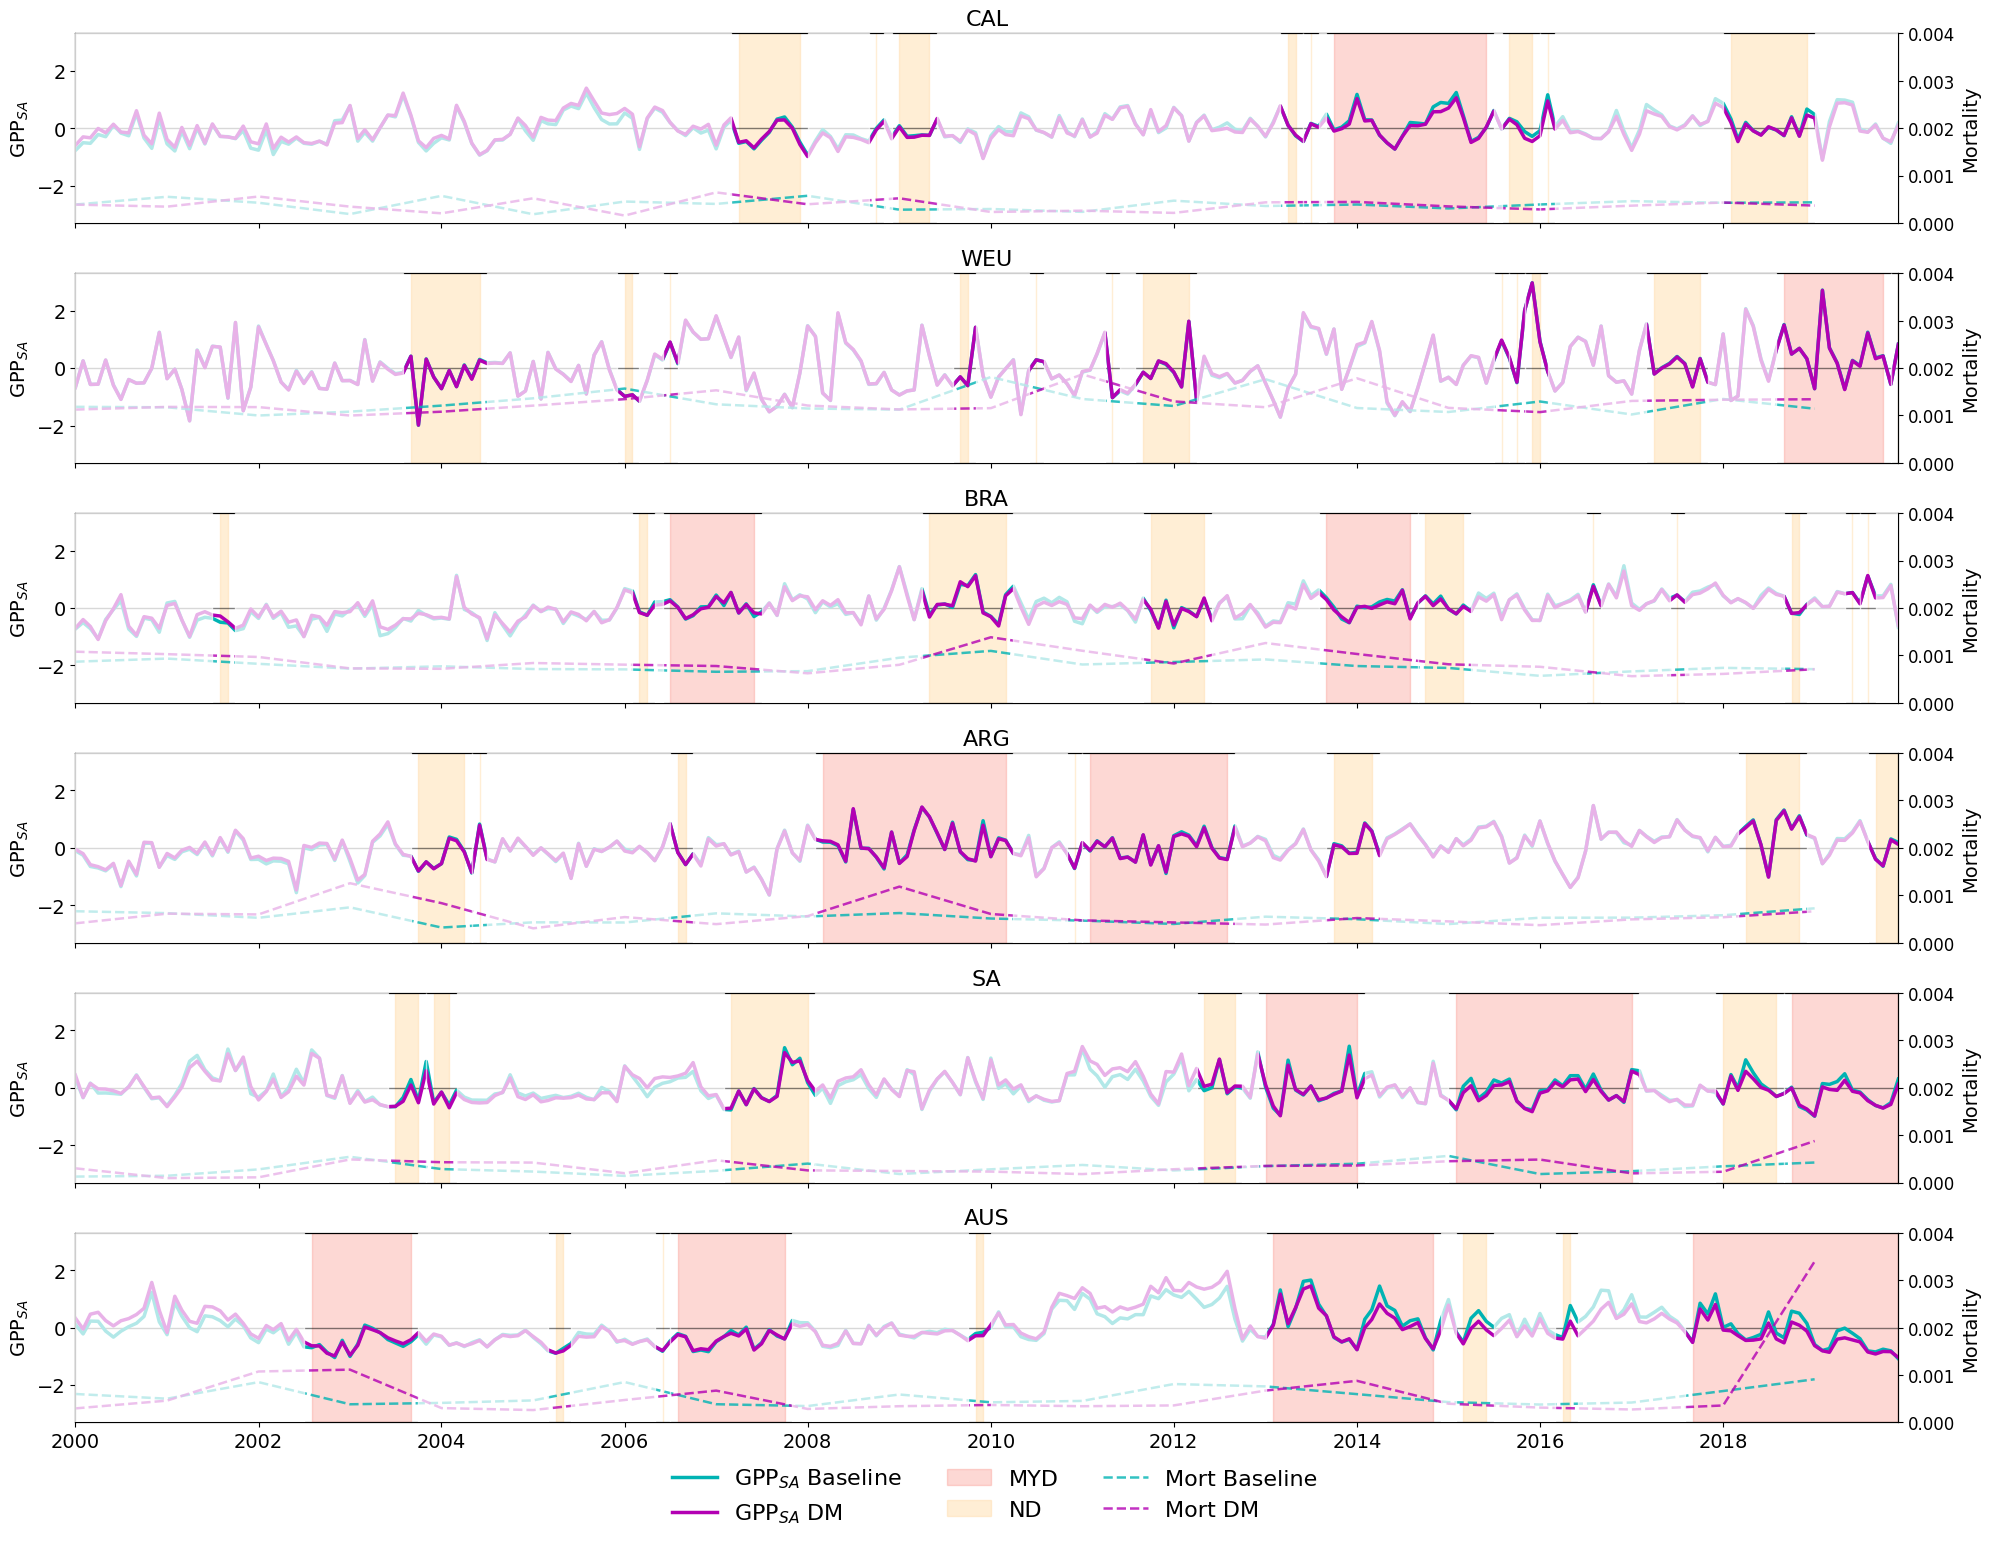

In [69]:
plot_all_regions(results_GPP, results_mort, region_settings)